In [ ]:
import pandas as pd
import io

# Using the already uploaded data from the 'uploaded' dictionary
file_name = 'marketing_campaign.csv'
if file_name in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=';')
    print("Columns after fix:", df.columns.tolist())
    display(df.head())

Columns after fix: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.isnull().sum()

,0
ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
print("Date conversion successful.")
df[['Dt_Customer']].head()

Date conversion successful.


,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


In [ ]:
import pandas as pd

# Identifying the actual channel and spending columns available
channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
spending = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Calculating totals
channel_totals = df[channels].sum().reset_index()
channel_totals.columns = ['Channel', 'Total_Purchases']

# Calculating total spending per customer to see general revenue potential
df['Total_Spending'] = df[spending].sum(axis=1)

print("Purchase distribution by channel:")
display(channel_totals)

print("\nSummary of Total Spending per Customer:")
display(df[['Total_Spending']].describe())

Purchase distribution by channel:


,Channel,Total_Purchases
0,NumWebPurchases,9150
1,NumCatalogPurchases,5963
2,NumStorePurchases,12970



Summary of Total Spending per Customer:


,Total_Spending
count,2240.000000
mean,605.798214
std,602.249288
min,5.000000
25%,68.750000
50%,396.000000
75%,1045.500000
max,2525.000000


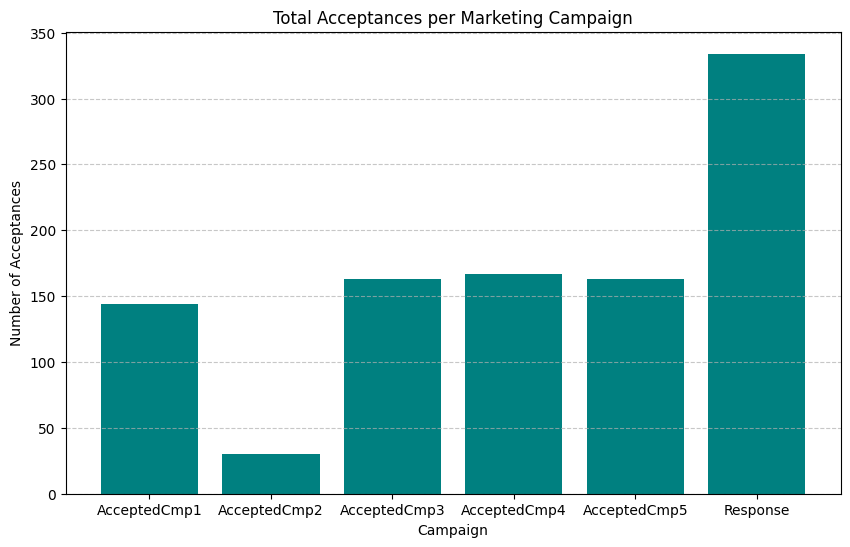

In [ ]:
import matplotlib.pyplot as plt

# Define the campaign columns present in the dataset
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
# Sum the binary values to get total acceptances
values = [df[c].sum() for c in campaigns]

plt.figure(figsize=(10, 6))
plt.bar(campaigns, values, color='teal')
plt.title('Total Acceptances per Marketing Campaign')
plt.xlabel('Campaign')
plt.ylabel('Number of Acceptances')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Current columns in df:", df.columns.tolist())

Current columns in df: ['ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response']


In [ ]:
# Rectifying the error by using existing columns
# We'll create a summary of purchases by the actual channels available
channel_summary = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum().reset_index()
channel_summary.columns = ['Channel', 'Total_Purchases']

# We can also look at total spending (Revenue proxy) across all products
total_rev = df['Total_Spending'].sum()

print("Corrected Channel Purchase Data:")
display(channel_summary)
print(f"\nTotal Revenue (Spending) across all customers: {total_rev}")

Corrected Channel Purchase Data:


,Channel,Total_Purchases
0,NumWebPurchases,9150
1,NumCatalogPurchases,5963
2,NumStorePurchases,12970



Total Revenue (Spending) across all customers: 1356988


In [ ]:
from google.colab import files

# Trigger download for the generated files
files.download('cleaned_marketing_data.csv')
files.download('marketing_analysis_summary.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Exporting the cleaned DataFrame to CSV
df.to_csv('cleaned_marketing_data.csv', index=False)

# Creating a summary report file
with open('marketing_analysis_summary.txt', 'w') as f:
    f.write('Marketing Campaign Analysis Summary\n')
    f.write('==================================\n\n')
    f.write(f'Total Customers: {len(df)}\n')
    f.write(f'Total Revenue (Spending): {df["Total_Spending"].sum():.2f}\n\n')
    f.write('Purchases by Channel:\n')
    f.write(channel_summary.to_string(index=False))
    f.write('\n\nCampaign Acceptance Totals:\n')
    for camp, val in zip(campaigns, values):
        f.write(f'{camp}: {val}\n')

print('Files created successfully: cleaned_marketing_data.csv, marketing_analysis_summary.txt')

Files created successfully: cleaned_marketing_data.csv, marketing_analysis_summary.txt
